# ResNet-50 – Multi-Label Classification
### DeepFashion2 – Top-5 Categories

**Prerequisite:** Run `preprocessing.ipynb` first so pruned data and DataLoaders are ready.

This notebook trains ResNet-50 for multi-label clothing classification:
- **From scratch** (random init)
- **Transfer learning** (ImageNet weights, frozen backbone)

## 1. Setup

In [1]:
# Kaggle: no drive mount needed
import os,gc,json
SAVE_DIR = "/kaggle/working/VR_Mini_Project-1"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Save dir:", SAVE_DIR)

Save dir: /kaggle/working/VR_Mini_Project-1


## 2. Re-run Preprocessing Imports

> These cells replicate the shared preprocessing state (label maps, datasets, loaders).
> Copy from `preprocessing.ipynb` or import from a shared script.

### 2a. Label Mapping

In [2]:
TOP5 = [1, 8, 7, 2, 9]
category_names = ['Short Sleeve Top', 'Trousers', 'Shorts', 'Long Sleeve Top', 'Skirt']
cat_to_idx = {cat_id: i for i, cat_id in enumerate(TOP5)}
idx_to_cat = {i: cat_id for cat_id, i in cat_to_idx.items()}

print("Index → Category:", idx_to_cat)

Index → Category: {0: 1, 1: 8, 2: 7, 3: 2, 4: 9}


### 2b. MultiLabelDataset

In [3]:
import os
import json
import torch
from torch.utils.data import Dataset
from PIL import Image

class MultiLabelDataset(Dataset):
    def __init__(self, image_dir, anno_dir, transform=None):
        self.image_dir = image_dir
        self.anno_dir = anno_dir
        self.transform = transform

        # Dynamically list all .jpg files in the directory
        self.images = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        # Load image
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        # Load annotation
        anno_name = img_name.replace(".jpg", ".json")
        anno_path = os.path.join(self.anno_dir, anno_name)

        with open(anno_path) as f:
            data = json.load(f)

        # Initialize a zero tensor for the TOP5 categories
        label = torch.zeros(len(TOP5))

        for key in data:
            cat_id = data[key]["category_id"]
            if cat_id in cat_to_idx:
                label[cat_to_idx[cat_id]] = 1.0

        if self.transform:
            image = self.transform(image)

        return image, label

### 2c. Transforms & Datasets

In [4]:
from torchvision import transforms

# ImageNet normalization stats (required for pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Train transform: augmentation + normalization (addresses class imbalance via augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    #transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Val/Test transform: only resize + normalize (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = MultiLabelDataset(
    "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_train/images",
    "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_train/annos",
    train_transform
)

val_dataset = MultiLabelDataset(
    "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_val/images",
    "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_val/annos",
    val_transform
)

test_dataset = MultiLabelDataset(
    "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/images",
    "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/annos",
    test_transform
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 122547
Val size: 23741
Test size: 21627


### 2d. Static Subset & DataLoaders

In [5]:
import numpy as np
from torch.utils.data import Subset, DataLoader

subset_size = int(len(train_dataset) * 0.5)

# Lock the random seed! This guarantees ResNet, EfficientNet,
# and MobileNet all get the EXACT same 50k images.
np.random.seed(42)
subset_indices = np.random.choice(len(train_dataset), subset_size, replace=False)

train_subset_50 = Subset(train_dataset, subset_indices)
print(f"Created a static subset of {len(train_subset_50)} images.")

Created a static subset of 61273 images.


In [6]:
from torch.utils.data import DataLoader

# Create training DataLoader
train_loader = DataLoader(
    train_subset_50,
    batch_size=64,      # Number of images per batch
    shuffle=True,       # Shuffle for training
    num_workers=4,      # Parallel loading (reduce if error)
    pin_memory=True
)

# Create validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,      # Do NOT shuffle validation data
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


## 3. Loss, Optimizer Helpers

In [7]:
import os
import json
import torch.nn as nn
from tqdm.notebook import tqdm
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def compute_pos_weight_subset(subset, num_classes, device):
    print("Calculating class weights for the 50% subset...")
    label_counts = torch.zeros(num_classes)

    # We have to dig into the subset to get the original dataset and our 50k indices
    base_dataset = subset.dataset

    for idx in tqdm(subset.indices):
        img_name = base_dataset.images[idx]
        anno_name = img_name.replace(".jpg", ".json")
        anno_path = os.path.join(base_dataset.anno_dir, anno_name)

        with open(anno_path) as f:
            data = json.load(f)

        for key in data:
            if key.startswith("item"):
                cat_id = data[key]["category_id"]
                if cat_id in cat_to_idx:  # Assuming your cat_to_idx dict is still in memory
                    label_counts[cat_to_idx[cat_id]] += 1

    total = len(subset.indices)
    neg_counts = total - label_counts
    pos_weight = neg_counts / (label_counts + 1e-6)

    print("\nNew pos_weight per class:", pos_weight)
    return pos_weight.to(device)

pos_weight = compute_pos_weight_subset(train_subset_50, num_classes=5, device=device)

# Binary Cross Entropy with Logits + pos_weight for class imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("Loss function and optimizer defined with class imbalance correction.")

from torch.amp import GradScaler

scaler = GradScaler('cuda')

Calculating class weights for the 50% subset...


  0%|          | 0/61273 [00:00<?, ?it/s]


New pos_weight per class: tensor([1.0074, 1.6091, 2.9137, 3.0153, 3.7166])
Loss function and optimizer defined with class imbalance correction.


## 4. Training Functions

In [8]:
from tqdm.notebook import tqdm

# --------------------------------------------------
# Function: Train model for ONE epoch
# --------------------------------------------------
from torch.amp import autocast

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()
    running_loss = 0.0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none = True)

        # Mixed precision forward pass
        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Scaled backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


# --------------------------------------------------
# Function: Validate model for ONE epoch
# --------------------------------------------------
from torch.amp import autocast

def validate_one_epoch(model, loader, criterion, device):

    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)

            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

In [9]:
def train_model(model, optimizer, save_path, device):

    num_epochs = 15
    best_val_loss = float('inf')
    epochs_no_improve = 0  # <-- NEW: Track how long we've been stuck

    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch+1}/{num_epochs}]")

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = validate_one_epoch(model, val_loader, criterion, device)

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")

        # Did we improve?
        if val_loss < best_val_loss:
            print(f"Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}. Saving model!")
            best_val_loss = val_loss
            state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
            torch.save(state_dict, save_path)

            epochs_no_improve = 0  # <-- NEW: Reset counter because we improved!

        # If we didn't improve...
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s).")

        gc.collect()
        torch.cuda.empty_cache()

    print("\nTraining complete! Best Validation Loss:", best_val_loss)

## 5. Evaluation Function

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from tqdm.notebook import tqdm

def evaluate_model(model, model_name, device, category_names):
    """
    Evaluates a PyTorch model on a test set and prints/plots the metrics.
    """
    model.eval()

    all_preds_probs = []
    all_true_labels = []

    print(f"Gathering predictions for {model_name}...")
    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images = images.to(device)

            # Forward pass
            outputs = model(images)

            # Apply sigmoid to get probabilities (0.0 to 1.0)
            probs = torch.sigmoid(outputs)

            # Move to CPU and convert to NumPy
            all_preds_probs.append(probs.cpu().numpy())
            all_true_labels.append(labels.cpu().numpy())

    # Stack lists into neat 2D NumPy arrays
    all_preds_probs = np.vstack(all_preds_probs)
    all_true_labels = np.vstack(all_true_labels)

    # Apply a 0.5 threshold to get strict binary predictions (0 or 1)
    binary_preds = (all_preds_probs > 0.5).astype(int)

    # ---------------------------------------------------------
    # 1. Per-Class Metrics
    # ---------------------------------------------------------
    precision = precision_score(all_true_labels, binary_preds, average=None, zero_division=0)
    recall = recall_score(all_true_labels, binary_preds, average=None, zero_division=0)
    f1_per_class = f1_score(all_true_labels, binary_preds, average=None, zero_division=0)
    auc_per_class = roc_auc_score(all_true_labels, all_preds_probs, average=None)

    print("\n" + "="*55)
    print(f"PER-CLASS EVALUATION REPORT: {model_name.upper()}")
    print("="*55)
    for i, cat in enumerate(category_names):
        print(f"Category: {cat}")
        print(f"  Precision: {precision[i]:.4f}")
        print(f"  Recall:    {recall[i]:.4f}")
        print(f"  F1-Score:  {f1_per_class[i]:.4f}")
        print(f"  AUC:       {auc_per_class[i]:.4f}\n")

    # ---------------------------------------------------------
    # 2. Averaged F1-Scores
    # ---------------------------------------------------------
    macro_f1 = f1_score(all_true_labels, binary_preds, average='macro', zero_division=0)
    micro_f1 = f1_score(all_true_labels, binary_preds, average='micro', zero_division=0)

    print("-" * 55)
    print(f"{model_name} Macro-Averaged F1-Score: {macro_f1:.4f}")
    print(f"{model_name} Micro-Averaged F1-Score: {micro_f1:.4f}")
    print("-" * 55)

    # ---------------------------------------------------------
    # 3. Plot ROC Curves
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 8))

    for i, cat in enumerate(category_names):
        fpr, tpr, _ = roc_curve(all_true_labels[:, i], all_preds_probs[:, i])
        plt.plot(fpr, tpr, lw=2, label=f'{cat} (AUC = {auc_per_class[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves per Class - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    # Returning these in case you want to save them to a dictionary later
    return macro_f1, micro_f1

## 6. ResNet-50 — Training From Scratch

In [11]:
# Training From Scratch (No Pretrained Weights)

import torch
import torch.nn as nn
import torchvision.models as models

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load ResNet-50 WITHOUT pretrained weights (from scratch)
model = models.resnet50(weights=None)

# Replace final fully connected layer
# Original output: 1000 classes
# New output: 5 classes (our TOP5 categories)
model.fc = nn.Linear(model.fc.in_features, 5)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

# Move model to device
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)



print("ResNet-50 initialized for multi-label classification.")

Using device: cuda
Using 2 GPUs!
ResNet-50 initialized for multi-label classification.


In [12]:
train_model(
    model=model,
    optimizer=optimizer,
    save_path="/kaggle/working/VR_Mini_Project-1/resnet50_scratch.pth",
    device=device
)


Epoch [1/15]


  0%|          | 0/958 [00:00<?, ?it/s]

  0%|          | 0/371 [00:00<?, ?it/s]

Train Loss: 0.9296
Val Loss: 0.9182
Validation loss improved from inf to 0.9182. Saving model!

Epoch [2/15]


  0%|          | 0/958 [00:00<?, ?it/s]

...

  0%|          | 0/371 [00:00<?, ?it/s]

Train Loss: 0.5280
Val Loss: 0.5854
Validation loss improved from 0.5912 to 0.5854. Saving model!

Epoch [15/15]


  0%|          | 0/958 [00:00<?, ?it/s]

  0%|          | 0/371 [00:00<?, ?it/s]

Train Loss: 0.5095
Val Loss: 0.6101
No improvement for 1 epoch(s).

Training complete! Best Validation Loss: 0.585379436985584


### Evaluate on Test Set

Gathering predictions for ResNet-50_scratch...


  0%|          | 0/338 [00:00<?, ?it/s]


PER-CLASS EVALUATION REPORT: RESNET-50_SCRATCH
Category: Short Sleeve Top
  Precision: 0.7505
  Recall:    0.7774
  F1-Score:  0.7637
  AUC:       0.8523

Category: Trousers
  Precision: 0.8055
  Recall:    0.9052
  F1-Score:  0.8525
  AUC:       0.9577

Category: Shorts
  Precision: 0.7860
  Recall:    0.7646
  F1-Score:  0.7752
  AUC:       0.9356

Category: Long Sleeve Top
  Precision: 0.4356
  Recall:    0.8947
  F1-Score:  0.5859
  AUC:       0.8533

Category: Skirt
  Precision: 0.5294
  Recall:    0.8013
  F1-Score:  0.6376
  AUC:       0.8875

-------------------------------------------------------
ResNet-50_scratch Macro-Averaged F1-Score: 0.7230
ResNet-50_scratch Micro-Averaged F1-Score: 0.7290
-------------------------------------------------------


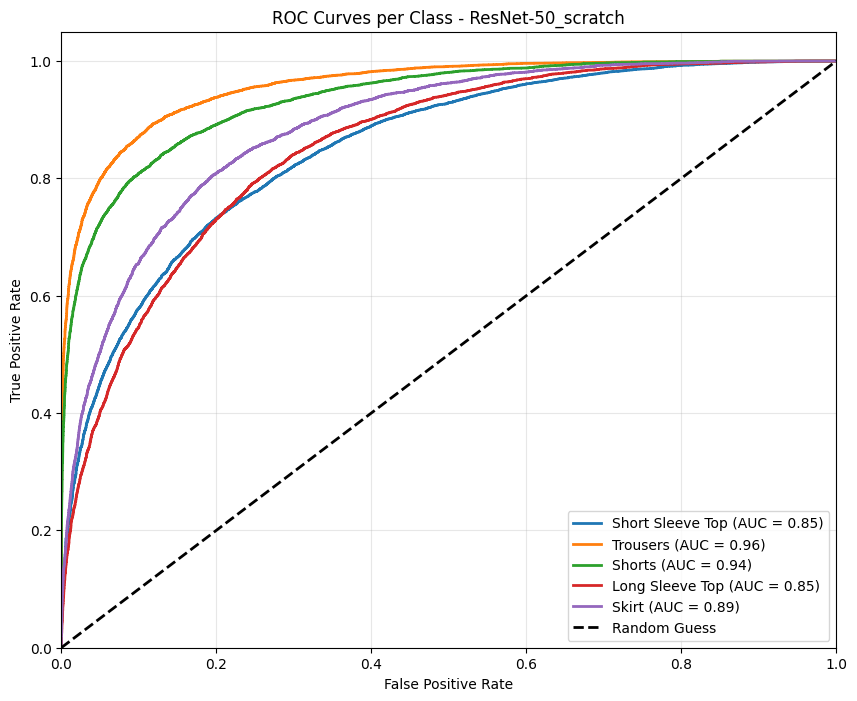

(0.722969176428478, 0.7289635825636953)

In [13]:
base_scratch = model.module if hasattr(model, 'module') else model
base_scratch.load_state_dict(
    torch.load("/kaggle/working/VR_Mini_Project-1/resnet50_scratch.pth", map_location=device)
)
evaluate_model(model, "ResNet-50_scratch", device, category_names)